In [22]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [23]:
path = 'Data\diabetes.csv'
data=pd.read_csv(path)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
data.shape

(768, 9)

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [26]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [27]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [28]:
columns_with_zeros=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in columns_with_zeros :
    zero_counts=(data[col]==0).sum()
    print(col,f"has {zero_counts} zero values ")


Glucose has 5 zero values 
BloodPressure has 35 zero values 
SkinThickness has 227 zero values 
Insulin has 374 zero values 
BMI has 11 zero values 


In [29]:
data[columns_with_zeros]=data[columns_with_zeros].replace(0,np.nan)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


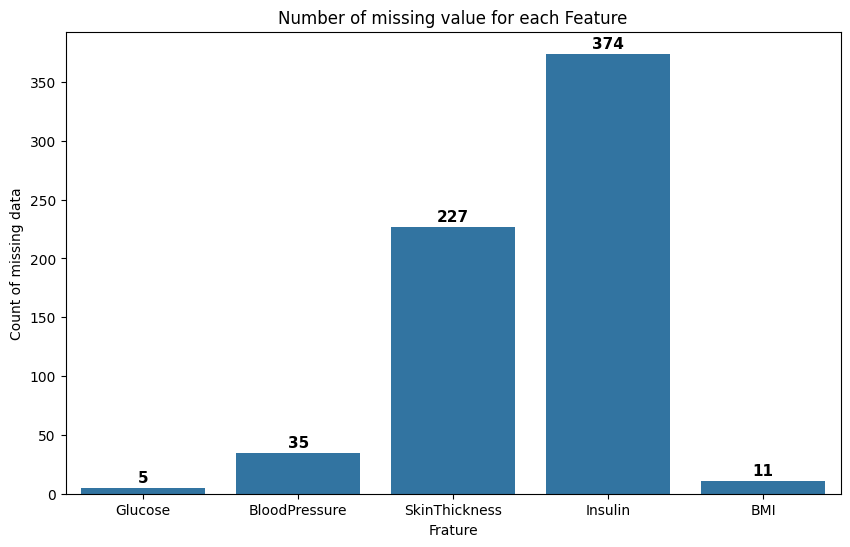

In [30]:
missing_data=data[columns_with_zeros].isnull().sum()
plt.figure(figsize=(10,6))
sns.barplot(x=missing_data.index,y=missing_data.values)
plt.title('Number of missing value for each Feature')
plt.xlabel('Frature')
plt.ylabel('Count of missing data')

for i , val in enumerate (missing_data.values):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()

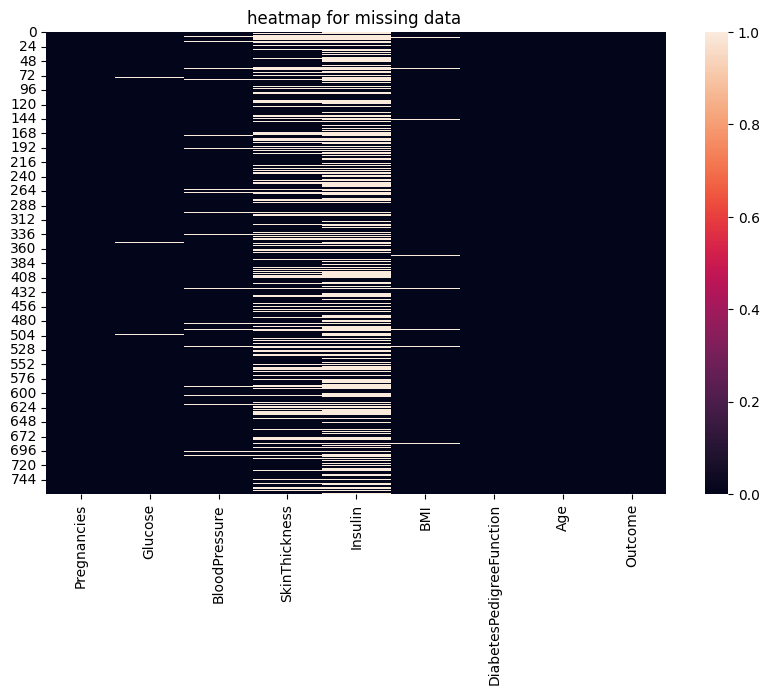

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(data.isnull())
plt.title('heatmap for missing data ')
plt.show()


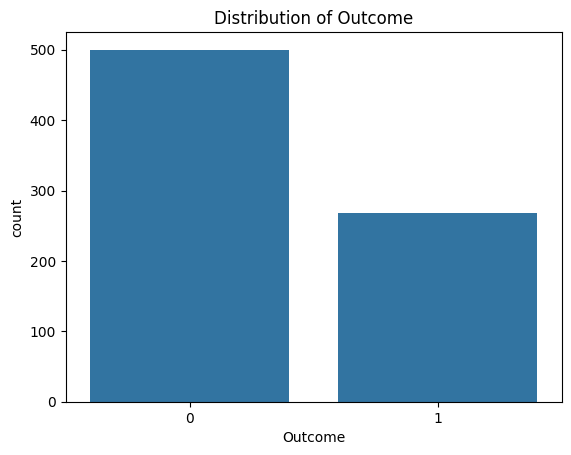

In [32]:
sns.countplot(x='Outcome',data=data)
plt.title('Distribution of Outcome')
plt.show()

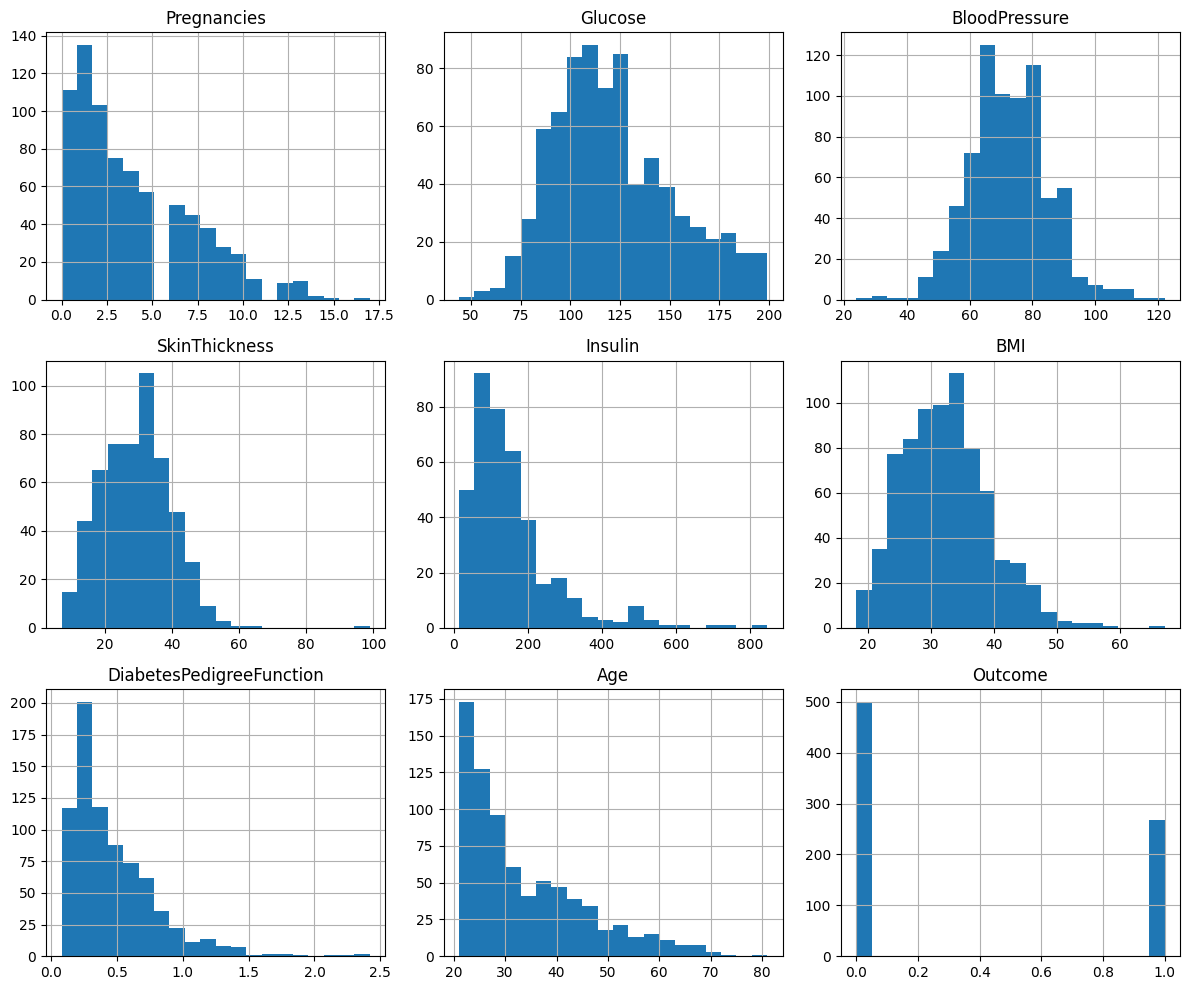

In [33]:
data.hist(figsize=(12,10),bins=20)
plt.tight_layout()
plt.show()

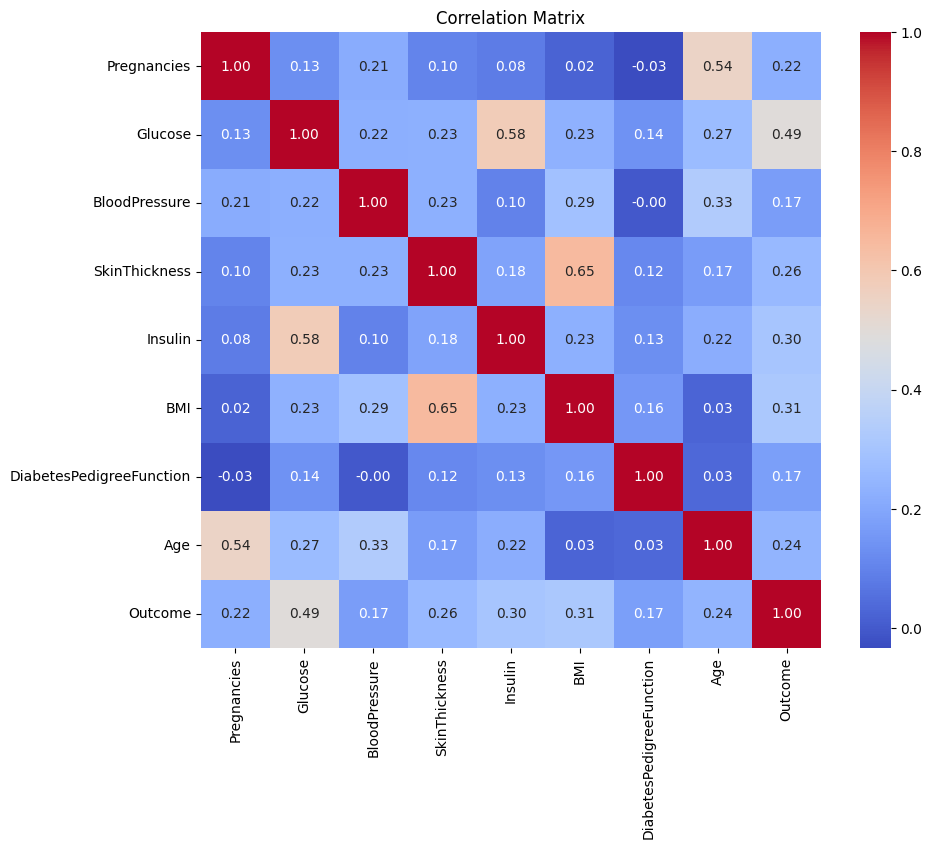

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

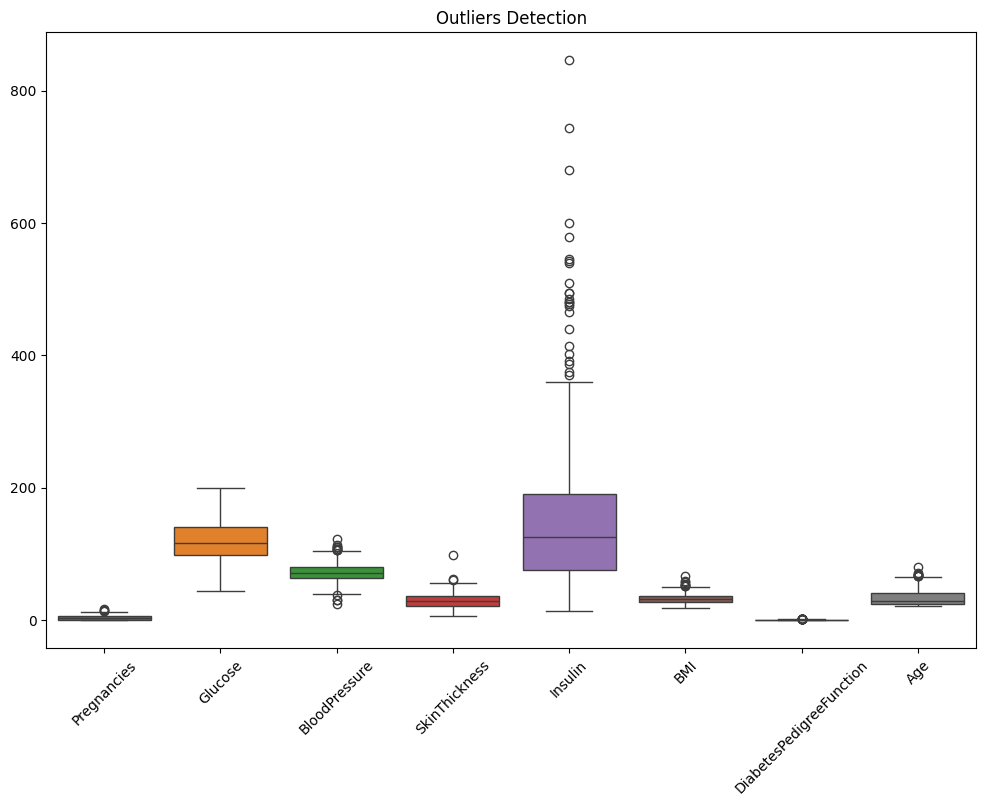

In [35]:
plt.figure(figsize=(12,8))
sns.boxplot(data=data.drop(columns=['Outcome']))
plt.title('Outliers Detection')
plt.xticks(rotation=45)
plt.show()

In [36]:
for col in columns_with_zeros:
    data[col]=data[col].fillna(data.groupby('Outcome')[col].transform('median'))

In [37]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [38]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [39]:
data.to_csv('Cleaned_data',index=False)

# Author: Eng. Amr Samir